In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.ndimage as ndi

from PIL import Image, ImageSequence
import tifffile as tiff


In [2]:
# -------- PATHS --------
DATA_ROOT = "/kaggle/input/vesuvius-challenge-surface-detection"
TRAIN_IMG_DIR = f"{DATA_ROOT}/train_images"
TRAIN_LBL_DIR = f"{DATA_ROOT}/train_labels"
TEST_IMG_DIR  = f"{DATA_ROOT}/test_images"

# -------- DEVICE --------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -------- GLOBAL KNOBS --------
PATCH_SIZE = 64
STRIDE = PATCH_SIZE // 2
BATCH_SIZE = 1
EPOCHS = 4            # default = 1 (you can increase)
LR = 1e-4
THRESHOLD = 0.35


Device: cuda


In [3]:
train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
test_df  = pd.read_csv(f"{DATA_ROOT}/test.csv")

print("Train samples:", len(train_df))
print("Test samples :", len(test_df))


Train samples: 806
Test samples : 1


In [4]:
def load_tiff_volume(path):
    """Submission-safe TIFF loader (handles LZW)."""
    im = Image.open(path)
    slices = []
    for page in ImageSequence.Iterator(im):
        slices.append(np.array(page))
    return np.stack(slices, axis=0)


In [5]:
from matplotlib.colors import ListedColormap

VESUVIUS_CMAP = ListedColormap(["black", "white", "red"])

def show_slices(volume, title="", is_label=False):
    D, H, W = volume.shape
    cz, cy, cx = D//2, H//2, W//2

    fig, axs = plt.subplots(1, 3, figsize=(12,4))

    axs[0].imshow(volume[cz], cmap=VESUVIUS_CMAP if is_label else "gray",
                  vmin=0, vmax=1, interpolation="nearest")
    axs[0].set_title(f"{title} XY")

    axs[1].imshow(volume[:, cy, :], cmap=VESUVIUS_CMAP if is_label else "gray",
                  vmin=0, vmax=1, interpolation="nearest")
    axs[1].set_title(f"{title} XZ")

    axs[2].imshow(volume[:, :, cx], cmap=VESUVIUS_CMAP if is_label else "gray",
                  vmin=0, vmax=1, interpolation="nearest")
    axs[2].set_title(f"{title} YZ")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [6]:
all_ids = train_df.id.tolist()
np.random.shuffle(all_ids)

val_ids = all_ids[:2]        # small validation
train_ids = all_ids[2:]


In [7]:
class VesuviusPatchDataset(Dataset):
    def __init__(self, ids):
        self.ids = ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        vid = self.ids[idx]

        img = load_tiff_volume(f"{TRAIN_IMG_DIR}/{vid}.tif").astype(np.float32) / 255.0
        lbl = load_tiff_volume(f"{TRAIN_LBL_DIR}/{vid}.tif")

        D, H, W = img.shape

        z = np.random.randint(0, D - PATCH_SIZE)
        y = np.random.randint(0, H - PATCH_SIZE)
        x = np.random.randint(0, W - PATCH_SIZE)

        img_p = img[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        lbl_p = lbl[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        ignore = (lbl_p == 2)
        lbl_bin = (lbl_p == 1).astype(np.float32)
        lbl_bin[ignore] = 0.0

        return (
            torch.from_numpy(img_p).unsqueeze(0),
            torch.from_numpy(lbl_bin).unsqueeze(0)
        )


In [8]:
class SimpleUNet3D(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i, o):
            return nn.Sequential(
                nn.Conv3d(i, o, 3, padding=1),
                nn.BatchNorm3d(o),
                nn.ReLU(inplace=True),
                nn.Conv3d(o, o, 3, padding=1),
                nn.BatchNorm3d(o),
                nn.ReLU(inplace=True),
            )

        self.enc1 = block(1, 16)
        self.enc2 = block(16, 32)
        self.enc3 = block(32, 64)

        self.pool = nn.MaxPool3d(2)

        self.bottleneck = block(64, 128)

        self.up3 = nn.ConvTranspose3d(128, 64, 2, 2)
        self.dec3 = block(128, 64)

        self.up2 = nn.ConvTranspose3d(64, 32, 2, 2)
        self.dec2 = block(64, 32)

        self.up1 = nn.ConvTranspose3d(32, 16, 2, 2)
        self.dec1 = block(32, 16)

        self.out = nn.Conv3d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)


In [9]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum()
    den = probs.sum() + targets.sum() + eps
    return 1 - num / den

def combo_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss(logits, targets)
    return 0.5 * bce + 0.5 * dice


In [10]:
train_ds = VesuviusPatchDataset(train_ids)
val_ds   = VesuviusPatchDataset(val_ids)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1)

model = SimpleUNet3D().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x, y in tqdm(train_loader, desc=f"Train {epoch+1}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = combo_loss(out, y)
        loss.backward()
        opt.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            val_loss += combo_loss(model(x), y).item()

    print(f"Epoch {epoch+1}: train={train_loss/len(train_loader):.4f}, val={val_loss/len(val_loader):.4f}")


Train 1: 100%|██████████| 804/804 [36:45<00:00,  2.74s/it]


Epoch 1: train=0.6707, val=0.5805


Train 2: 100%|██████████| 804/804 [23:37<00:00,  1.76s/it]


Epoch 2: train=0.6334, val=0.6815


Train 3: 100%|██████████| 804/804 [23:34<00:00,  1.76s/it]


Epoch 3: train=0.6185, val=0.6945


Train 4: 100%|██████████| 804/804 [23:39<00:00,  1.77s/it]


Epoch 4: train=0.6093, val=0.6692


In [11]:
def infer_full_volume(model, vol):
    model.eval()
    D, H, W = vol.shape
    prob = np.zeros((D,H,W), np.float32)
    cnt  = np.zeros((D,H,W), np.float32)

    with torch.no_grad():
        for z in range(0, D-PATCH_SIZE+1, STRIDE):
            for y in range(0, H-PATCH_SIZE+1, STRIDE):
                for x in range(0, W-PATCH_SIZE+1, STRIDE):
                    p = vol[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                    p = torch.from_numpy(p).unsqueeze(0).unsqueeze(0).to(DEVICE)
                    out = torch.sigmoid(model(p))[0,0].cpu().numpy()
                    prob[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE] += out
                    cnt[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1

    prob /= np.maximum(cnt, 1e-6)

    print("Prob stats:", prob.min(), prob.mean(), prob.max())
    return (prob > THRESHOLD).astype(np.uint8)


Prob stats: 0.008561171 0.12816717 0.58653617


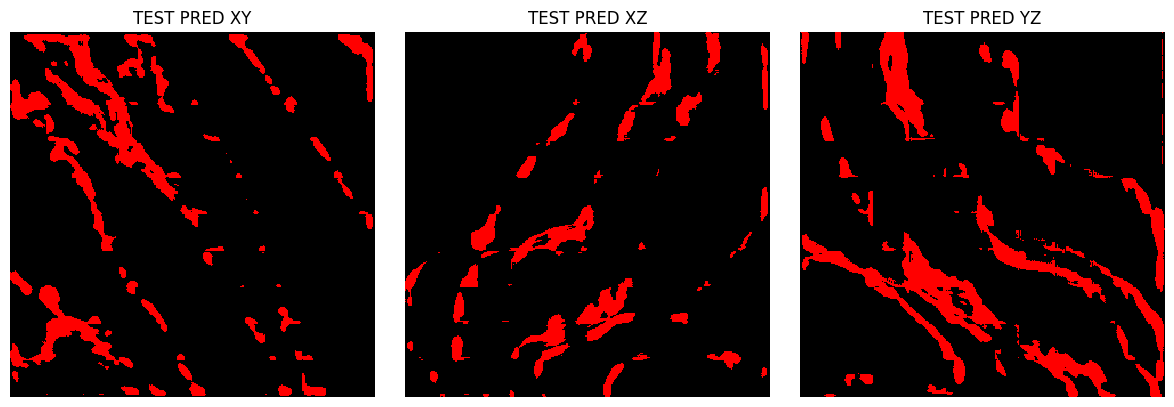

In [12]:
tid = test_df.id.iloc[0]
test_vol = load_tiff_volume(f"{TEST_IMG_DIR}/{tid}.tif").astype(np.float32) / 255.0

pred = infer_full_volume(model, test_vol)
show_slices(pred, "TEST PRED", is_label=True)


Visualizing GT vs PRED for volume: 3904609999
Prob stats: 0.036182705 0.3098218 0.6075882


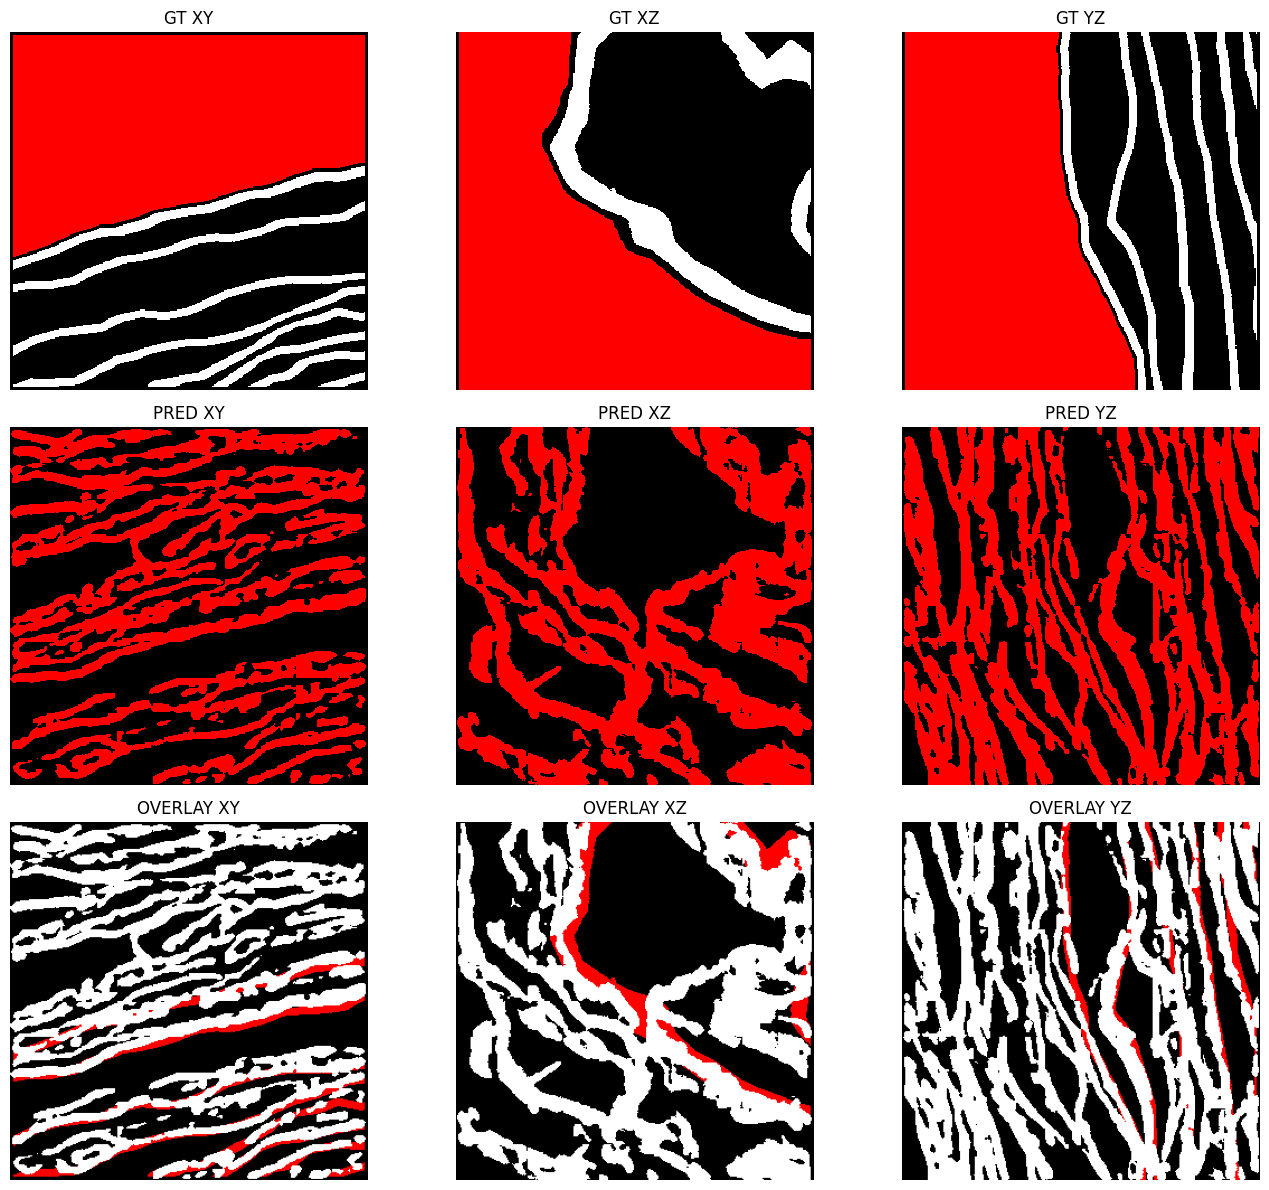

GT foreground voxels   : 3988634
PRED foreground voxels : 13981895
Intersection voxels    : 2681302


In [13]:
# pick a validation volume (or any TRAIN id)
vid = val_ids[1]
print("Visualizing GT vs PRED for volume:", vid)

# load volume + GT
img = load_tiff_volume(f"{TRAIN_IMG_DIR}/{vid}.tif").astype(np.float32) / 255.0
gt  = load_tiff_volume(f"{TRAIN_LBL_DIR}/{vid}.tif")

# run inference
pred = infer_full_volume(model, img)

# binarize explicitly (safety)
pred = (pred > 0).astype(np.uint8)

# choose center slices
D, H, W = img.shape
cz, cy, cx = D//2, H//2, W//2

# -------- visualization --------
fig, axs = plt.subplots(3, 3, figsize=(14, 12))

# ----- GT -----
axs[0,0].imshow(gt[cz], cmap=VESUVIUS_CMAP, vmin=0, vmax=2, interpolation="nearest")
axs[0,0].set_title("GT XY")

axs[0,1].imshow(gt[:, cy, :], cmap=VESUVIUS_CMAP, vmin=0, vmax=2, interpolation="nearest")
axs[0,1].set_title("GT XZ")

axs[0,2].imshow(gt[:, :, cx], cmap=VESUVIUS_CMAP, vmin=0, vmax=2, interpolation="nearest")
axs[0,2].set_title("GT YZ")

# ----- PRED -----
axs[1,0].imshow(pred[cz], cmap=VESUVIUS_CMAP, vmin=0, vmax=1, interpolation="nearest")
axs[1,0].set_title("PRED XY")

axs[1,1].imshow(pred[:, cy, :], cmap=VESUVIUS_CMAP, vmin=0, vmax=1, interpolation="nearest")
axs[1,1].set_title("PRED XZ")

axs[1,2].imshow(pred[:, :, cx], cmap=VESUVIUS_CMAP, vmin=0, vmax=1, interpolation="nearest")
axs[1,2].set_title("PRED YZ")

# ----- OVERLAY (GT in red, PRED in white) -----
overlay_xy = np.zeros((gt[cz].shape[0], gt[cz].shape[1], 3), dtype=np.uint8)
overlay_xy[gt[cz] == 1] = [255, 0, 0]     # GT papyrus = red
overlay_xy[pred[cz] == 1] = [255, 255, 255]  # PRED = white

overlay_xz = np.zeros((gt[:, cy, :].shape[0], gt[:, cy, :].shape[1], 3), dtype=np.uint8)
overlay_xz[gt[:, cy, :] == 1] = [255, 0, 0]
overlay_xz[pred[:, cy, :] == 1] = [255, 255, 255]

overlay_yz = np.zeros((gt[:, :, cx].shape[0], gt[:, :, cx].shape[1], 3), dtype=np.uint8)
overlay_yz[gt[:, :, cx] == 1] = [255, 0, 0]
overlay_yz[pred[:, :, cx] == 1] = [255, 255, 255]

axs[2,0].imshow(overlay_xy)
axs[2,0].set_title("OVERLAY XY")

axs[2,1].imshow(overlay_xz)
axs[2,1].set_title("OVERLAY XZ")

axs[2,2].imshow(overlay_yz)
axs[2,2].set_title("OVERLAY YZ")

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()

# -------- stats --------
print("GT foreground voxels   :", (gt == 1).sum())
print("PRED foreground voxels :", pred.sum())
print("Intersection voxels    :", ((gt == 1) & (pred == 1)).sum())


In [14]:
os.makedirs("submission", exist_ok=True)

for vid in tqdm(test_df.id):
    vol = load_tiff_volume(f"{TEST_IMG_DIR}/{vid}.tif").astype(np.float32) / 255.0
    pred = infer_full_volume(model, vol)
    tiff.imwrite(f"submission/{vid}.tif", pred.astype(np.uint8))


100%|██████████| 1/1 [00:16<00:00, 16.31s/it]

Prob stats: 0.008561171 0.12816717 0.58653617


In [15]:
import shutil
shutil.make_archive("submission", "zip", "submission")
print("submission.zip ready")


submission.zip ready
